# 04 · Cohort Retention Analysis

**Goal:** answer *"of the customers who first bought in month X, what % came back 1, 2, 3 … months later?"*

> 📘 **What's a cohort?** A group of customers who share a starting point, here their **first purchase month**. Tracking each cohort separately avoids a classic trap: total customer counts can look stable even while old customers leave and new ones replace them.
>
> **Banking parallel:** the same technique is used for account attrition, credit-card activation, and loan vintage analysis ("vintage curves" in credit risk are essentially cohort charts).

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGS = ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid")

sales = pd.read_parquet(PROCESSED / "sales_clean.parquet")
cs = sales[sales["HasCustomer"]].copy()

## 1. Assign each customer to a cohort and compute "months since first purchase"

In [2]:
cs["OrderMonth"] = cs["InvoiceDate"].dt.to_period("M")
cs["CohortMonth"] = cs.groupby("CustomerID")["OrderMonth"].transform("min")
cs["MonthIndex"] = (cs["OrderMonth"] - cs["CohortMonth"]).apply(lambda d: d.n)

cohort_counts = (cs.groupby(["CohortMonth", "MonthIndex"])["CustomerID"].nunique()
                   .unstack(fill_value=0))
cohort_size = cohort_counts[0]
retention = cohort_counts.div(cohort_size, axis=0)
# Mask cells in the future (a Jan-2011 cohort can't have a month-20 value yet)
last = cs["OrderMonth"].max()
for cohort in retention.index:
    retention.loc[cohort, retention.columns > (last - cohort).n] = np.nan
retention.iloc[:6, :8].round(3)

MonthIndex,0,1,2,3,4,5,6,7
CohortMonth,,,,,,,,
2009-12,1.0,0.350,0.333,0.425,0.379,0.360,0.376,0.344
2010-01,1.0,0.215,0.321,0.315,0.272,0.310,0.269,0.234
2010-02,1.0,0.235,0.227,0.293,0.245,0.197,0.192,0.288
2010-03,1.0,0.190,0.231,0.243,0.231,0.204,0.247,0.306
2010-04,1.0,0.190,0.190,0.160,0.184,0.221,0.276,0.265
2010-05,1.0,0.157,0.169,0.176,0.176,0.255,0.212,0.125


## 2. Retention heatmap
Read it **row by row** (one cohort's journey) and **column by column** (compare cohorts at the same age).

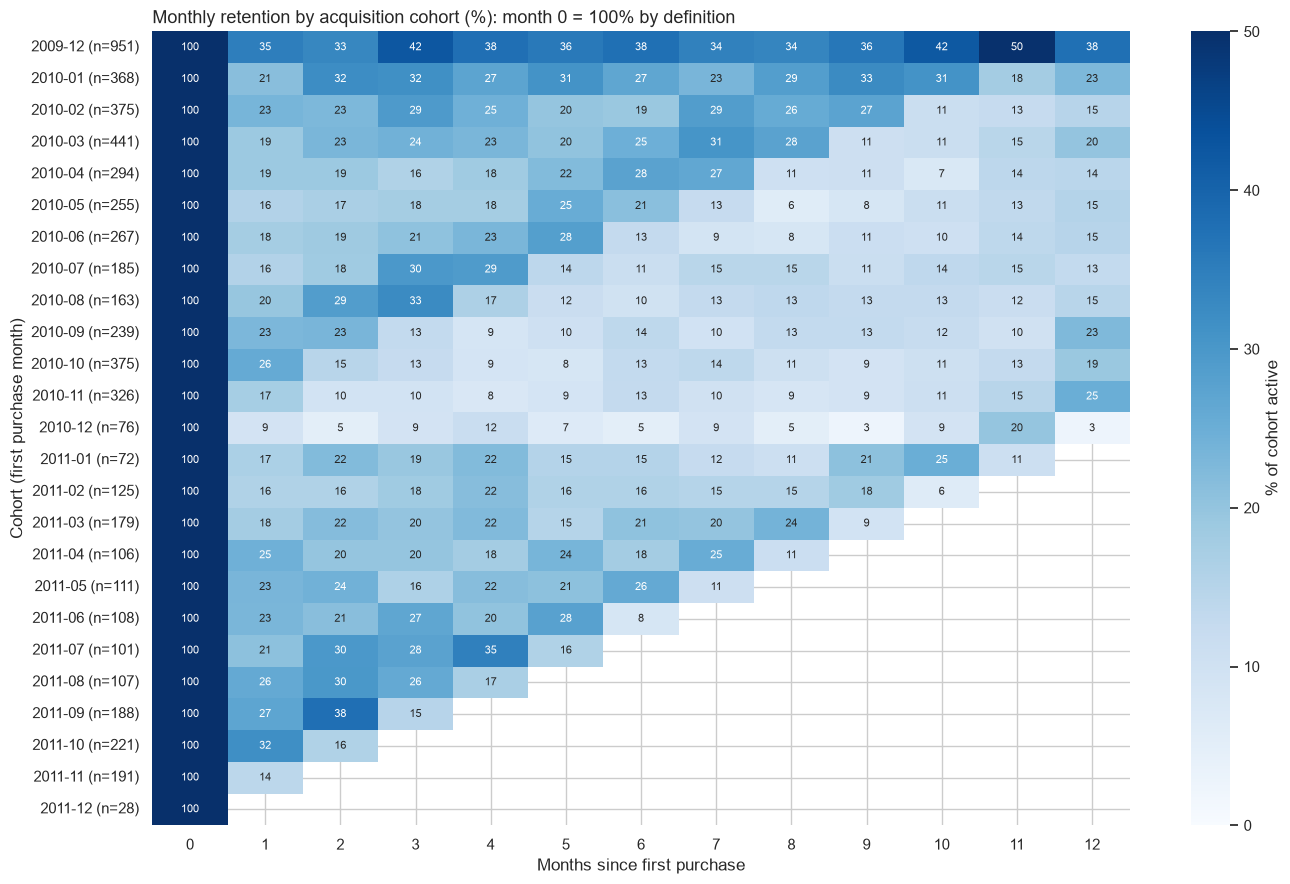

In [3]:
show = retention.iloc[:, :13]  # first 12 months after acquisition
fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(show * 100, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=50, ax=ax,
            cbar_kws={"label": "% of cohort active"}, annot_kws={"size": 8})
ax.set_yticklabels([f"{c} (n={cohort_size[c]})" for c in show.index], rotation=0)
ax.set_title("Monthly retention by acquisition cohort (%): month 0 = 100% by definition", loc="left", fontsize=13)
ax.set_xlabel("Months since first purchase"); ax.set_ylabel("Cohort (first purchase month)")
plt.tight_layout(); plt.savefig(FIGS / "04_cohort_heatmap.png", dpi=150); plt.show()

## 3. Average retention curve
⚠️ **Caveat:** the **Dec-2009 cohort is special**: data starts in Dec-2009, so it contains *all existing* customers, not just new ones. Its retention is much higher. We exclude it from the "new customer" average.

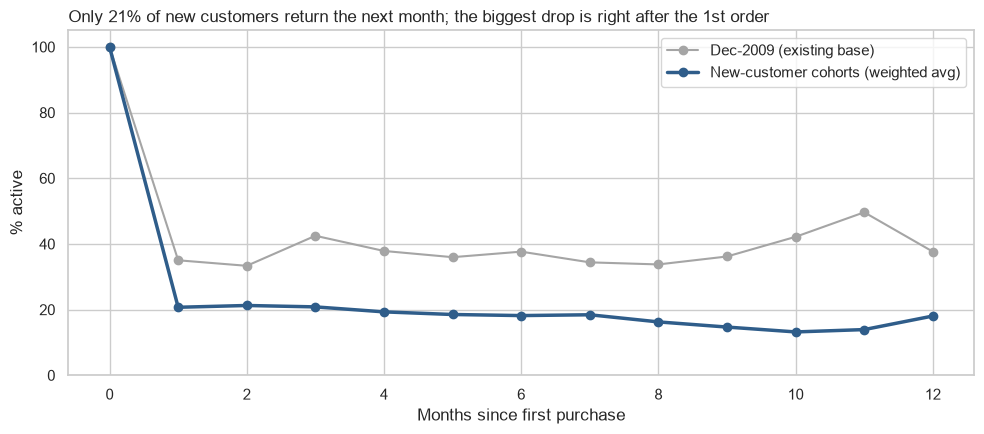

Month  1 retention (new customers): 20.7%
Month  3 retention (new customers): 20.8%
Month  6 retention (new customers): 18.2%
Month 12 retention (new customers): 18.0%


In [4]:
new_cohorts = retention.drop(index=retention.index[0])
weights = cohort_size.drop(index=cohort_size.index[0])
avg_curve = new_cohorts.apply(lambda col: np.average(col.dropna(), weights=weights[col.notna()]) if col.notna().any() else np.nan)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(retention.columns[:13], retention.iloc[0, :13] * 100, "o-", color="#A5A5A5", label="Dec-2009 (existing base)")
ax.plot(avg_curve.index[:13], avg_curve.values[:13] * 100, "o-", color="#2F5D8A", lw=2.5, label="New-customer cohorts (weighted avg)")
ax.set_title(f"Only {avg_curve[1]:.0%} of new customers return the next month; the biggest drop is right after the 1st order",
             loc="left", fontsize=12)
ax.set_xlabel("Months since first purchase"); ax.set_ylabel("% active"); ax.legend(); ax.set_ylim(0, 105)
plt.tight_layout(); plt.savefig(FIGS / "04_retention_curve.png", dpi=150); plt.show()

for m in [1, 3, 6, 12]:
    print(f"Month {m:>2} retention (new customers): {avg_curve[m]:.1%}")

## 4. One-time buyers
How many customers **never** come back after their first order? This is the single biggest lever.

In [5]:
orders_per_cust = cs.groupby("CustomerID")["Invoice"].nunique()
one_timers = (orders_per_cust == 1).mean()
print(f"{one_timers:.1%} of customers placed only ONE order.")
print(f"Customers with 2+ orders spend on average "
      f"£{cs.groupby('CustomerID')['Revenue'].sum()[orders_per_cust > 1].mean():,.0f} vs "
      f"£{cs.groupby('CustomerID')['Revenue'].sum()[orders_per_cust == 1].mean():,.0f} for one-timers.")

27.7% of customers placed only ONE order.
Customers with 2+ orders spend on average £3,826 vs £343 for one-timers.


## 5. Export (long format suits Power BI matrix visuals)

In [6]:
out = (retention.stack().dropna().rename("RetentionRate").reset_index()
       .rename(columns={"CohortMonth": "Cohort"}))
out["Cohort"] = out["Cohort"].astype(str)
out["CohortSize"] = out["Cohort"].map({str(k): v for k, v in cohort_size.items()})
out["ActiveCustomers"] = (out["RetentionRate"] * out["CohortSize"]).round().astype(int)
out.to_csv(PROCESSED / "cohort_retention.csv", index=False)
print(f"Saved cohort_retention.csv ({len(out)} rows)")

Saved cohort_retention.csv (325 rows)


## ✅ Key takeaways
1. The biggest customer loss happens **right after the first order**, so a "second-purchase" onboarding journey is the highest-ROI retention action.
2. Retention stabilises after a few months: customers who stick around become loyal.
3. Q4 bumps show up diagonally in the heatmap (seasonal re-purchase), which is consistent with the Q4 revenue peak.

**Limitation:** the first cohort is left-censored (includes pre-existing customers); recent cohorts have few months of history.